In [ ]:
import torch_fidelity
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project.models.blocks import SpectralNormDecoder, Encoder
from vae_project import Trainer, get_dataset, VAE, langevin_dynamics

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
bs = 128
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)
xb, yb = next(iter(train_dl))

In [ ]:
K_train = 5  # importance samples during training
K_eval = 50  # tighter bound for evaluation
seed = 42
latent_dim = 16
h_dim = 64
wd = 1e-4
channels = (3, 32, 64, 128)
epochs = 15
lr = 1e-3

random_seed(seed)
collate_fn = CollateWithTransforms(batch_tfms or [])

dl_kwargs = dict(collate_fn=collate_fn, num_workers=6, persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
val_dl = DataLoader(val_ds, batch_size=bs, **dl_kwargs)

recon_dist = 'bce'
encoder = Encoder(channels, latent_dim=latent_dim, input_size=(32,32), h_dim=h_dim)
decoder = SpectralNormDecoder(channels[::-1], latent_dim=latent_dim, enc_final_shape=encoder.final_shape, h_dim=h_dim)
model = VAE(encoder, decoder, recon_dist=recon_dist)

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
hooks = [MetricsHook(), ProgressBarHook()]

trainer_config = dict(
    model=model,
    train_dl=train_dl,
    valid_dl=val_dl,
    optim=optimizer,
    epochs=epochs,
    hooks=hooks,
)

trainer = Trainer(**trainer_config)

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/15 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 510.7549 | Val Loss: 344.3998


Epoch 2/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 14/15 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 190.3615 | Val Loss: 189.9672


Epoch 15/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15/15 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 189.0462 | Val Loss: 188.8394


In [ ]:
t.save(model, 'model.pt')

## FID, KID and other scores

In [ ]:
from vae_project.evaluate import evaluate_model
# have to use this slower dataset to match api of torch_fidelity
ds = ColoredMNIST('../data', train=False, color_type='label')
metrics = evaluate_model(model, ds)

Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Extracting features from input1
Processing samples
Extracting features from input2
Processing samples
Inception Score: 1.9332376641291216 ± 0.053367436937508846
Frechet Inception Distance: 48.42447647718237
Kernel Inception Distance: 0.03465231418609619 ± 0.0009308840565172013


In [ ]:
metrics

{'inception_score_mean': 1.9332376641291216,
 'inception_score_std': 0.053367436937508846,
 'frechet_inception_distance': 48.42447647718237,
 'kernel_inception_distance_mean': 0.03465231418609619,
 'kernel_inception_distance_std': 0.0009308840565172013}

## Samples

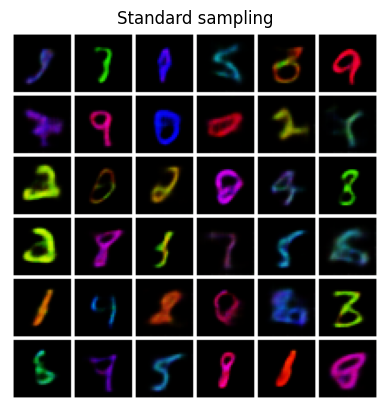

In [ ]:
n_samples = 36
show_imgs(model.sample(n_samples), title='Standard sampling')
plt.axis('off')
plt.show()

## Langevin dynamics

In [ ]:
from vae_project.utils import show_imgs

def compare_dynamics(model, xb, n_steps=100, step_sz=0.1):
    orig, refined, _ = langevin_dynamics(model, xb, n_steps=n_steps, step_sz=step_sz)
    
    # Visual Comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    show_imgs(xb.cpu(), ax=ax1, title="Original Input")
    show_imgs(orig.cpu(), ax=ax2, title="Standard Reconstruction")
    show_imgs(refined.cpu(), ax=ax3, title=f"Langevin Reconstruction ({n_steps} steps)")
    for a in (ax1, ax2, ax3): a.axis('off')
    plt.show()

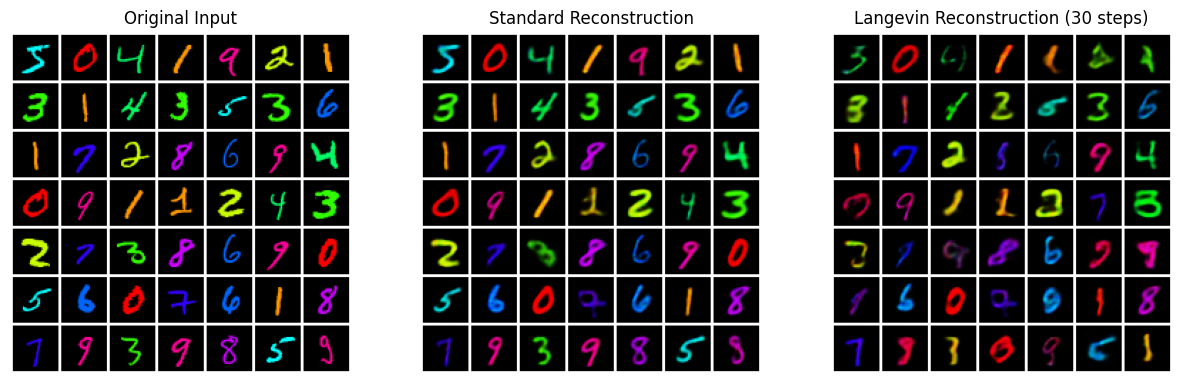

In [ ]:
compare_dynamics(model, to_device(xb[:49],trainer.device), n_steps=30, step_sz=0.02)

In [ ]:
x = xb[:49].to(trainer.device)
x_orig, x_ref, z_final, hist_b = langevin_dynamics(model, x, n_steps=100, return_hist=True, step_sz=0.02)

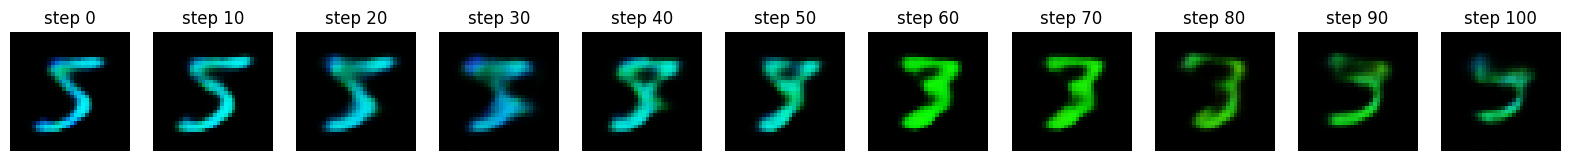

In [ ]:
hist = hist_b[0]
steps_idx = np.arange(len(hist), step=10, dtype=np.int32)
steps = hist[steps_idx]
decoded_steps = [model.decode(z.to(trainer.device))[0] for z in steps]

fig, axes = plt.subplots(1, len(decoded_steps), figsize=(20, 2))
for ax, i, img in zip(axes, steps_idx, decoded_steps):
    show_img(img.cpu(), ax, title=f'step {i}')
    ax.axis('off')
plt.show()

<matplotlib.colorbar.Colorbar>

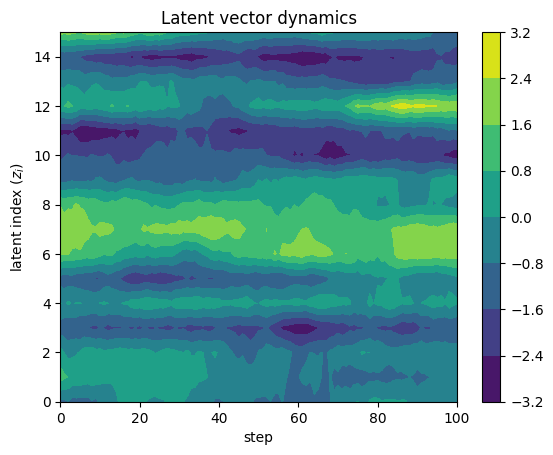

In [ ]:
plt.contourf(hist.T)
plt.xlabel('step')
plt.ylabel('latent index ($z_i$)')
plt.title("Latent vector dynamics")
plt.colorbar()

In [ ]:
from IPython.display import display, Image as IPImage
from PIL import Image

def animate_langevin(hist, fn='langevin.gif', fps=20, scale=5):
    with t.no_grad():
        z_seq = hist.to(trainer.device)
        frames = model.decode(z_seq)
    frames = F.interpolate(frames.cpu(), scale_factor=scale, mode='nearest')
    if frames.min() < 0: frames = (frames + 1) / 2
    frames = frames.clamp(0, 1).mul(255).byte().permute(0, 2, 3, 1)
    imgs = [Image.fromarray(f) for f in frames.numpy()]
    
    imgs[0].save(fn, save_all=True, append_images=imgs[1:], duration=1000//fps, loop=0)
    print(f"Saved animation to {fn}")
    return display(IPImage(filename=fn))

Saved animation to langevin.gif


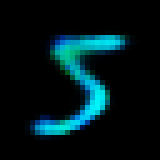

In [ ]:
animate_langevin(hist)

![](langevin.gif)